# Model Comparison — Surrogate Models

Compare GP vs other surrogate models (e.g. SVM, MLP) on the same function data.
Use this to decide which surrogate to use in **weekly_workflow.ipynb**.

GP, SVR (bootstrap ensemble), and MLP (PyTorch, MC Dropout) are available; use the comparison and LOO cells to choose a surrogate per function.

## 1. Setup and load data

In [1]:
import sys
from pathlib import Path
root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(root))

import numpy as np
from src.data import FunctionData, DATA_DIR, initialize_all_weeks
from src.surrogates import GPSurrogate, SVMSurrogate, MLPSurrogate, SurrogateModel
from src.acquisition import optimize_acquisition_enhanced
from src.utils import visualize_2d_surface, analyze_function

np.random.seed(42)
functions = {i: FunctionData(i, data_dir=DATA_DIR) for i in range(1, 9)}
initialize_all_weeks(functions)
print("✓ Data loaded")

INITIALIZING FUNCTIONS FROM HISTORICAL DATA
Source: /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/data/results
Loading weeks: [1, 2, 3, 4]

✓ Loaded Week 1 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/data/results/week_1
✓ Week 1: Updated 8 functions
✓ Loaded Week 2 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/data/results/week_2
✓ Week 2: Updated 8 functions
✓ Loaded Week 3 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/data/results/week_3
✓ Week 3: Updated 8 functions
✓ Loaded Week 4 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/data/results/week_4
✓ Week 4: Updated 8 functions

✓ Initialization complete: 4 weeks loaded

Function states:
  Function 1 (2D): 14 samples, best=0.000000
  Function 2 (2D): 14 samples, best=0.620709
  Function 3 (3D): 19 samples, best=-0.022206
  Function 4 (4D): 34 samples, best=0.661171
  Function 5 (4

## 2. Compare surrogates on one function

Pick a function (e.g. 1 or 2 for 2D visualization). Fit GP and, when available, SVM/MLP; compare suggested next query and predictions.

In [2]:
func_id = 1  # Change to 1 or 2 for 2D plots
func_data = functions[func_id]

models = {
    "GP": GPSurrogate(length_scale=0.5, optimize=True),
    "SVR": SVMSurrogate(C=10.0, epsilon=0.1, n_bootstrap=20),
    "MLP": MLPSurrogate(hidden_sizes=(64, 32), dropout=0.1, n_mc_samples=50),
}

for name, surrogate in models.items():
    surrogate.fit(func_data.inputs, func_data.outputs)
    x, mu, sigma = optimize_acquisition_enhanced(surrogate, func_data, acq_func="ucb", beta=2.0)
    print(f"{name}: next query = {np.array2string(x, precision=4)}, pred mean = {mu:.4f}, std = {sigma:.4f}")

GP: next query = [0.7421 0.8052], pred mean = 0.0000, std = 0.0008


## 3. Visualize (2D only)

For functions 1 and 2, plot surrogate mean and uncertainty.

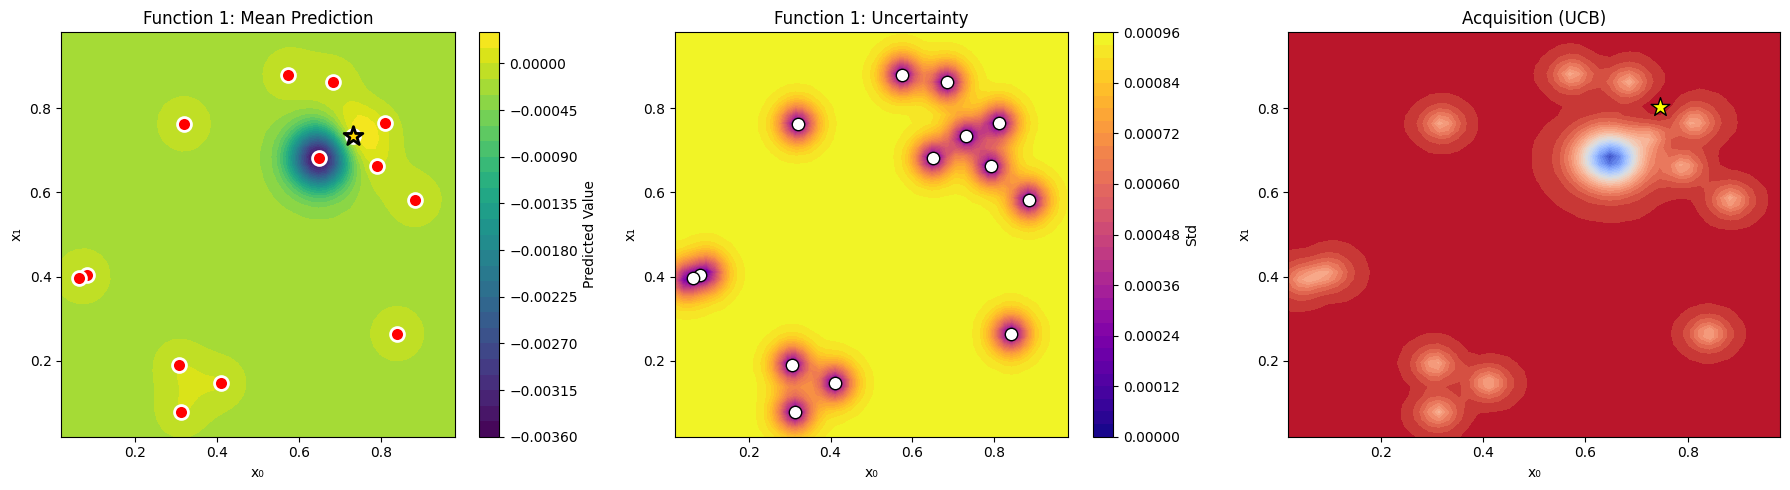

In [3]:
if func_data.n_dims == 2:
    gp = GPSurrogate(length_scale=0.5, optimize=True)
    gp.fit(func_data.inputs, func_data.outputs)
    visualize_2d_surface(func_id, functions, surrogate=gp, show_acquisition=True, acq_func="ucb", beta=2.0)

## 4. Full analysis with GP

Run full analysis (suggested query + 2D plot) for one function using GP.

In [ ]:
next_query, surrogate = analyze_function(func_id, functions, surrogate=None, acq_func="ucb", beta=2.0)

## 5. Leave-one-out cross-validation

Compute LOO RMSE for each surrogate per function to help decide which model to trust.

In [ ]:
from sklearn.model_selection import LeaveOneOut

surrogate_classes = {
    "GP": lambda: GPSurrogate(length_scale=0.5, optimize=True),
    "SVR": lambda: SVMSurrogate(C=10.0, epsilon=0.1, n_bootstrap=20),
    "MLP": lambda: MLPSurrogate(hidden_sizes=(64, 32), dropout=0.1, n_mc_samples=30),
}
loo = LeaveOneOut()
results = {name: [] for name in surrogate_classes}
for func_id in range(1, 9):
    fd = functions[func_id]
    X, y = fd.inputs, fd.outputs
    n = len(y)
    for name, factory in surrogate_classes.items():
        errs = []
        for train_idx, test_idx in loo.split(X):
            X_train, y_train = X[train_idx], y[train_idx]
            X_test, y_test = X[test_idx], y[test_idx]
            surr = factory()
            surr.fit(X_train, y_train)
            pred_mean, _ = surr.predict(X_test)
            errs.append((pred_mean[0] - y_test[0]) ** 2)
        rmse = np.sqrt(np.mean(errs))
        results[name].append(rmse)
print("LOO RMSE per function (GP / SVR / MLP):")
for func_id in range(1, 9):
    gp_r, svr_r, mlp_r = results["GP"][func_id - 1], results["SVR"][func_id - 1], results["MLP"][func_id - 1]
    print(f"  F{func_id}: {gp_r:.6f} / {svr_r:.6f} / {mlp_r:.6f}")
print("\nMean LOO RMSE across functions:")
for name in surrogate_classes:
    print(f"  {name}: {np.mean(results[name]):.6f}")